# Tau Bubble Chart (All Countries)

Interactive notebook to inspect all-country sector bubbles for `tau`, `tau_dir`, `tau_amp`, or `tau_amp2`.
Markers are fixed-size, small, and transparent to reduce clutter.

In [129]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz as viz
importlib.reload(viz)
prepare_all_countries_bubble_data = viz.prepare_all_countries_bubble_data
plot_all_countries_boxen = viz.plot_all_countries_boxen
import matplotlib.pyplot as plt


In [130]:
cfg = load_config('config/default.yaml')
year = 2015
metric = 'tau_amp'  # one of: tau, tau_dir, tau_amp, tau_amp2
group_col = 'sector_abbreviation'  # use abbreviations on axis
mark_buckets = True
yscale = 'log'  # 'linear' or 'log'
flip_axes = True
metric_clip_quantiles = (0.02, 0.995)
metric_decimals = 3
weighted = True
weight_col = 'out_proxy'  # sector output weight
fit_median_regression = True
show_points = True
point_alpha = 0.1
point_size = 3.0
bubble_size = 16.0  # still used in data prep; ignored by boxen plot


In [131]:
df = prepare_all_countries_bubble_data(
    cfg=cfg,
    year=year,
    metric=metric,
    bubble_size=bubble_size,
)
print(df[['label', 'country_code', 'sector_code', metric]].head(10).to_string(index=False))
print(f"rows={len(df)}  countries={df['country_code'].nunique()}  year={year}  metric={metric}")


  label country_code sector_code  tau_amp
AGO_A01          AGO         A01 0.044591
ARE_A01          ARE         A01 0.011580
ARG_A01          ARG         A01 0.019294
AUS_A01          AUS         A01 0.018590
AUT_A01          AUT         A01 0.022935
BEL_A01          BEL         A01 0.028402
BGD_A01          BGD         A01 0.010064
BGR_A01          BGR         A01 0.042001
BLR_A01          BLR         A01 0.045262
BRA_A01          BRA         A01 0.039695
rows=3888  countries=81  year=2015  metric=tau_amp


<Figure size 2200x1000 with 0 Axes>

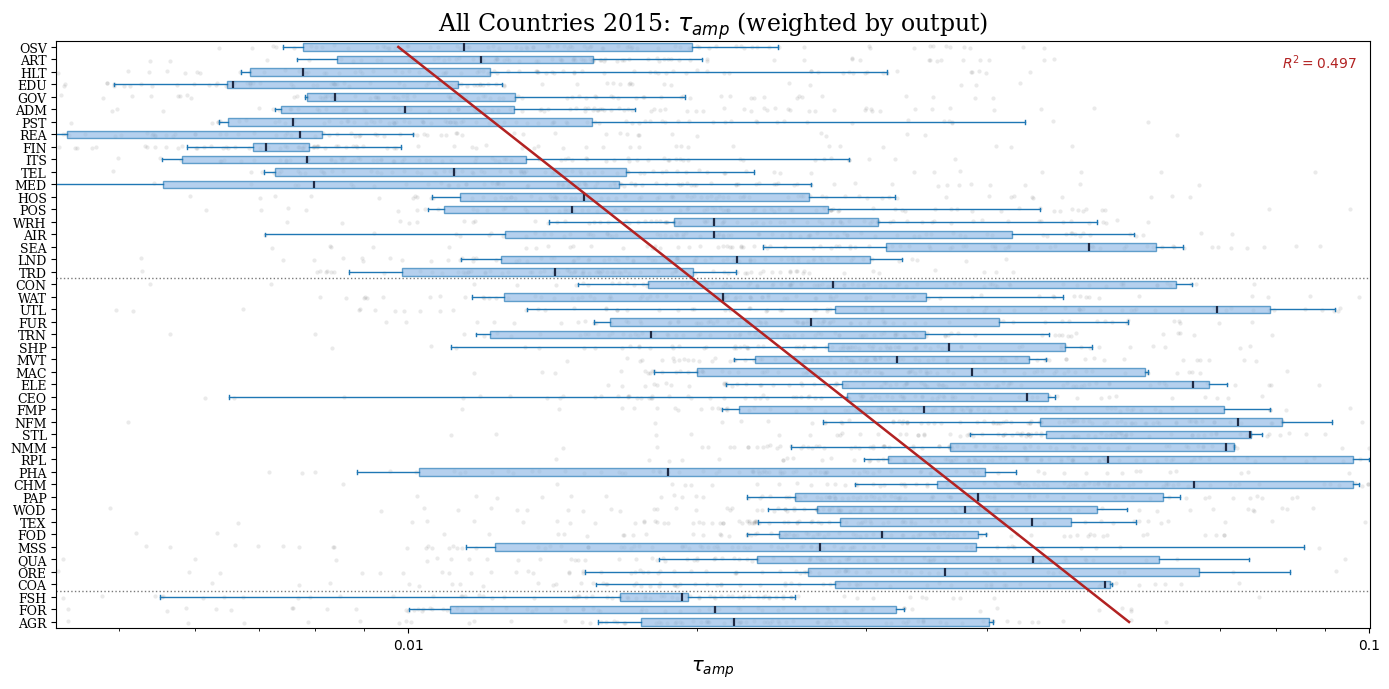

Regression R^2 (weighted medians): 0.4974


In [132]:
metric_labels = {
    'tau': r'$\tau$',
    'tau_dir': r'$\tau_{dir}$',
    'tau_amp': r'$\tau_{amp}$',
    'tau_amp2': r'$\tau$ with $\tau_{amp}$ tails',
}
metric_label = metric_labels.get(metric, metric)
weight_note = 'weighted by output' if weighted else 'unweighted'
title = f'All Countries {year}: {metric_label} ({weight_note})'

plt.figure(figsize=(22, 10))
ax = plot_all_countries_boxen(
    df,
    metric=metric,
    group_col=group_col,
    mark_buckets=mark_buckets,
    yscale=yscale,
    flip_axes=flip_axes,
    metric_clip_quantiles=metric_clip_quantiles,
    metric_decimals=metric_decimals,
    weighted=weighted,
    weight_col=weight_col,
    fit_median_regression=fit_median_regression,
    report_r2=True,
    title=title,
    show_points=show_points,
    point_alpha=point_alpha,
    point_size=point_size,
)
plt.tight_layout()
plt.show()
r2 = getattr(ax, '_median_regression_r2', float('nan'))
print(f'Regression R^2 (weighted medians): {r2:.4f}' if r2 == r2 else 'Regression R^2 unavailable')


## Try Different Inputs

- Change `year` (1995-2022)
- Change `metric` (`tau`, `tau_dir`, `tau_amp`, `tau_amp2`)
- Toggle `show_points` and tune `point_alpha` / `point_size` for clutter control
